In [ ]:
# Import library standar
import os
import numpy as np
import matplotlib.pyplot as plt
import pywt  # Pustaka PyWavelets untuk Analisis CWT

# Mengaktifkan Google Drive (Jika belum di-mount secara manual)
from google.colab import drive
drive.mount('/content/drive')

# Frekuensi sampling standar Dataset Bonn University
fs = 173.61

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==============================================================================
# GANTI BAGIAN INI SESUAIKAN DENGAN LOKASI FOLDER DI GOOGLE DRIVE ANDA
folder_path_Z = '/content/drive/MyDrive/Pengolahan_Sinyal/z/Z' # Contoh Path Folder Z
folder_path_S = '/content/drive/MyDrive/Pengolahan_Sinyal/s/S' # Contoh Path Folder S
# ==============================================================================

def load_100_signals(folder_path, prefix):
    """Fungsi untuk membaca file txt dari 001 hingga 100 ke dalam matriks"""
    signals = []
    for i in range(1, 101):
        # Format nama file misalnya Z001.txt, Z002.txt (Mendukung .txt huruf kecil/besar)
        file_name = os.path.join(folder_path, f"{prefix}{i:03d}.txt")

        # Cek jika file menggunakan ekstensi huruf kapital (.TXT)
        if not os.path.exists(file_name):
            file_name = os.path.join(folder_path, f"{prefix}{i:03d}.TXT")

        try:
            data = np.loadtxt(file_name)
            signals.append(data)
        except Exception as e:
            print(f"Error membaca {file_name}: {e}")

    return np.array(signals)

print("Sedang memuat data dari Google Drive...")
# Memuat ke-100 data ke dalam memori komputer
# Ukuran matriks nantinya adalah (100 pasien/segmen, 4097 sampel)
eeg_Z_100 = load_100_signals(folder_path_Z, 'Z')
eeg_S_100 = load_100_signals(folder_path_S, 'S')

print(f"Berhasil memuat Set Z (Sehat): {eeg_Z_100.shape[0]} file, {eeg_Z_100.shape[1]} titik data per file.")
print(f"Berhasil memuat Set S (Kejang): {eeg_S_100.shape[0]} file, {eeg_S_100.shape[1]} titik data per file.")

Sedang memuat data dari Google Drive...
Berhasil memuat Set Z (Sehat): 100 file, 4097 titik data per file.
Berhasil memuat Set S (Kejang): 100 file, 4097 titik data per file.


<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-302/3920044575.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Amplitudo ($\mu$V)')
/tmp/ipython-input-302/3920044575.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Amplitudo ($\mu$V)')


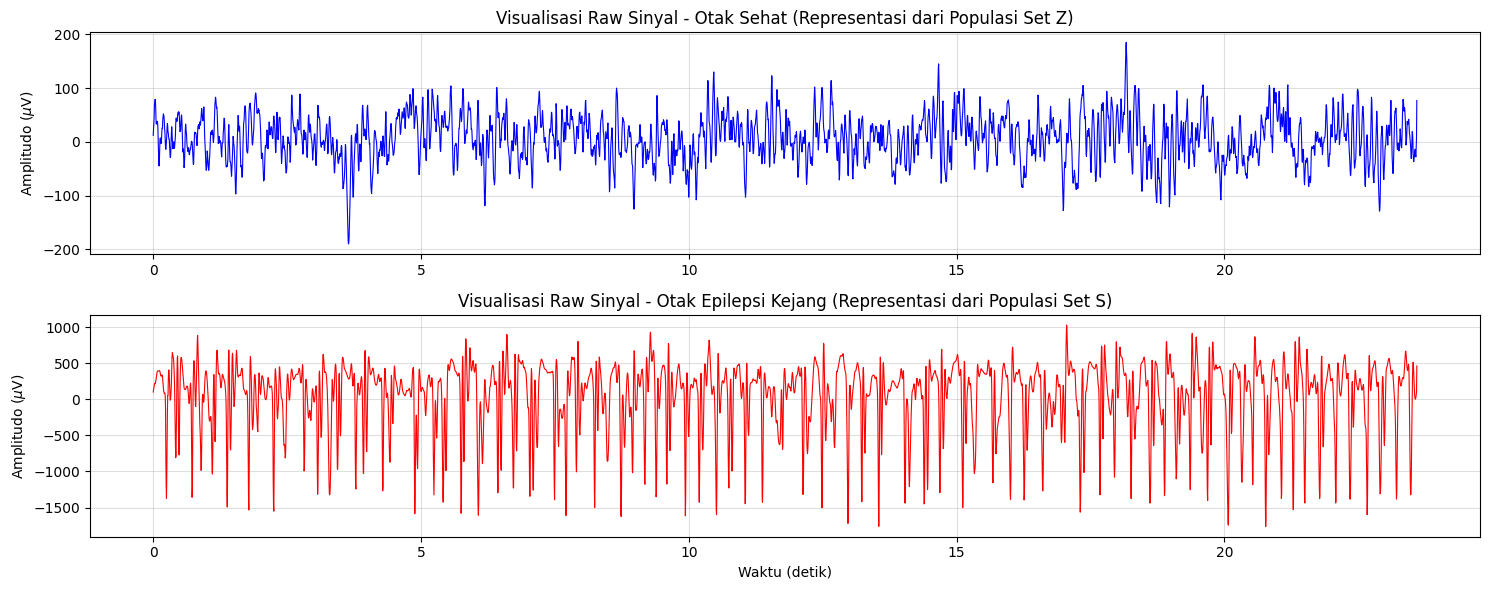

In [ ]:
# Membuat vektor waktu (durasi sekitar 23.6 detik)
time_vector = np.arange(eeg_Z_100.shape[1]) / fs

plt.figure(figsize=(15, 6))

# Plot 1 sampel representatif dari Set Z
plt.subplot(2, 1, 1)
plt.plot(time_vector, eeg_Z_100[0], color='blue', linewidth=0.8)
plt.title('Visualisasi Raw Sinyal - Otak Sehat (Representasi dari Populasi Set Z)')
plt.ylabel('Amplitudo ($\mu$V)')
plt.grid(True, alpha=0.4)

# Plot 1 sampel representatif dari Set S
plt.subplot(2, 1, 2)
plt.plot(time_vector, eeg_S_100[0], color='red', linewidth=0.8)
plt.title('Visualisasi Raw Sinyal - Otak Epilepsi Kejang (Representasi dari Populasi Set S)')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo ($\mu$V)')
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Sedang memproses Scalogram menggunakan Continuous Wavelet Transform (CWT)...


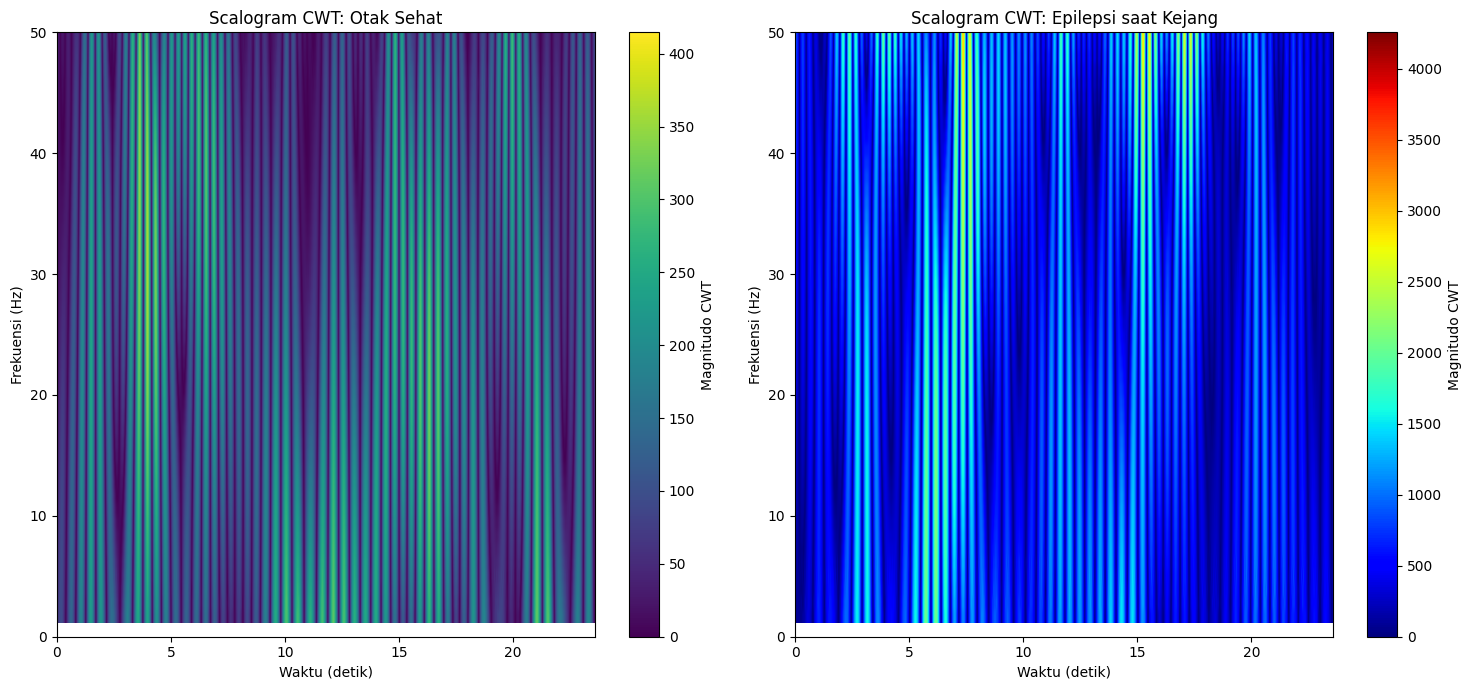

In [ ]:
print("Sedang memproses Scalogram menggunakan Continuous Wavelet Transform (CWT)...")

# Menggunakan Mother Wavelet 'morl' (Morlet) yang paling optimal untuk EEG
wavelet_name = 'morl'
scales = np.arange(1, 128) # Mendeteksi rentang frekuensi

# Mengambil sinyal representatif dari matriks 100 file yang sudah di-load
signal_Z = eeg_Z_100[0]
signal_S = eeg_S_100[0]

# Ekstraksi CWT
coef_Z, freqs_Z = pywt.cwt(signal_Z, scales, wavelet_name, sampling_period=1/fs)
coef_S, freqs_S = pywt.cwt(signal_S, scales, wavelet_name, sampling_period=1/fs)

# Batas visualisasi frekuensi maksimal di 50 Hz
freq_limit = 50

plt.figure(figsize=(15, 7))

# Plot Scalogram Sehat
plt.subplot(1, 2, 1)
im1 = plt.imshow(np.abs(coef_Z), extent=[0, time_vector[-1], freqs_Z[-1], freqs_Z[0]],
                 aspect='auto', cmap='viridis', vmin=0, vmax=np.abs(coef_Z).max())
plt.title('Scalogram CWT: Otak Sehat')
plt.ylabel('Frekuensi (Hz)')
plt.xlabel('Waktu (detik)')
plt.ylim(0, freq_limit)
plt.colorbar(im1, label='Magnitudo CWT')

# Plot Scalogram Epilepsi
plt.subplot(1, 2, 2)
im2 = plt.imshow(np.abs(coef_S), extent=[0, time_vector[-1], freqs_S[-1], freqs_S[0]],
                 aspect='auto', cmap='jet', vmin=0, vmax=np.abs(coef_S).max())
plt.title('Scalogram CWT: Epilepsi saat Kejang')
plt.ylabel('Frekuensi (Hz)')
plt.xlabel('Waktu (detik)')
plt.ylim(0, freq_limit)
plt.colorbar(im2, label='Magnitudo CWT')

plt.tight_layout()
plt.show()